## Objective
### Claim Outcome Classification 
- Business Purpose: Predict whether an insurance claim will be Paid, Pending, or Rejected before 
submission. 
- Define the target variable as claim_status. 
- Engineer financial and operational predictor features. 
- Perform a time-based train and test split. 
- Train baseline and advanced classification models. 
- Analyze class imbalance and mitigation strategy.

## ‼️ We will be using PyCaret only for this model. We have already demonstrated other skills in previous model construction

In [31]:
# ============================================================
# All Imports & Reproducibility Configuration
# ============================================================

import random
import os
import warnings

import pprint
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    roc_auc_score,
    roc_curve,
    auc,
)
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier

from data_profiling import ProfileReport
from pycaret.classification import *

# ============================================================
# Reproducibility — Single source of truth for all random seeds
# ============================================================
RANDOM_STATE = 42

random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
os.environ["PYTHONHASHSEED"] = str(RANDOM_STATE)

warnings.filterwarnings("ignore")

# Plot defaults
plt.rcParams["figure.dpi"] = 120
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["font.size"] = 11

print("All imports loaded. RANDOM_STATE =", RANDOM_STATE)

All imports loaded. RANDOM_STATE = 42


In [32]:
# ============================================================
# Load Data
# ============================================================

DATA_PATH = "../../Database/model_table.csv"
df = pd.read_csv(DATA_PATH, parse_dates=["visit_date", "registration_date", "billing_date"])

# Sort by visit_date immediately — ensures temporal order for all downstream operations
df = df.sort_values("visit_date").reset_index(drop=True)

In [33]:
# All columns list
"""
patient_id                             int64
age                                    int64
gender                                object
city                                  object
insurance_provider                    object
chronic_flag                           int64
registration_date             datetime64[ns]
visit_id                               int64
visit_date                    datetime64[ns]
department                            object
visit_type                            object
length_of_stay_hours                 float64
risk_score                            object
doctor_id                              int64
bill_id                                int64
billed_amount                        float64
approved_amount                      float64
claim_status                          object
payment_days                         float64
billing_date                  datetime64[ns]
visit_frequency                        int64
avg_length_of_stay                   float64
days_since_registration                int64
total_billed                         float64
avg_payment_days                     float64
provider_rejection_rate              float64
doctor_rejection_rate                float64
visit_month                            int64
visit_day_of_week                      int64
visit_quarter                          int64
is_weekend                             int64
days_between_reg_and_visit             int64
billing_delay_days                     int64
"""

'\npatient_id                             int64\nage                                    int64\ngender                                object\ncity                                  object\ninsurance_provider                    object\nchronic_flag                           int64\nregistration_date             datetime64[ns]\nvisit_id                               int64\nvisit_date                    datetime64[ns]\ndepartment                            object\nvisit_type                            object\nlength_of_stay_hours                 float64\nrisk_score                            object\ndoctor_id                              int64\nbill_id                                int64\nbilled_amount                        float64\napproved_amount                      float64\nclaim_status                          object\npayment_days                         float64\nbilling_date                  datetime64[ns]\nvisit_frequency                        int64\navg_length_of_stay             

In [34]:
# "Lag Time" (the gap between treatment and billing). 
# Delays in filing often lead to claim rejections due to "timely filing" limits.
df["lag_time"] = (df["billing_date"] - df["visit_date"]).dt.days

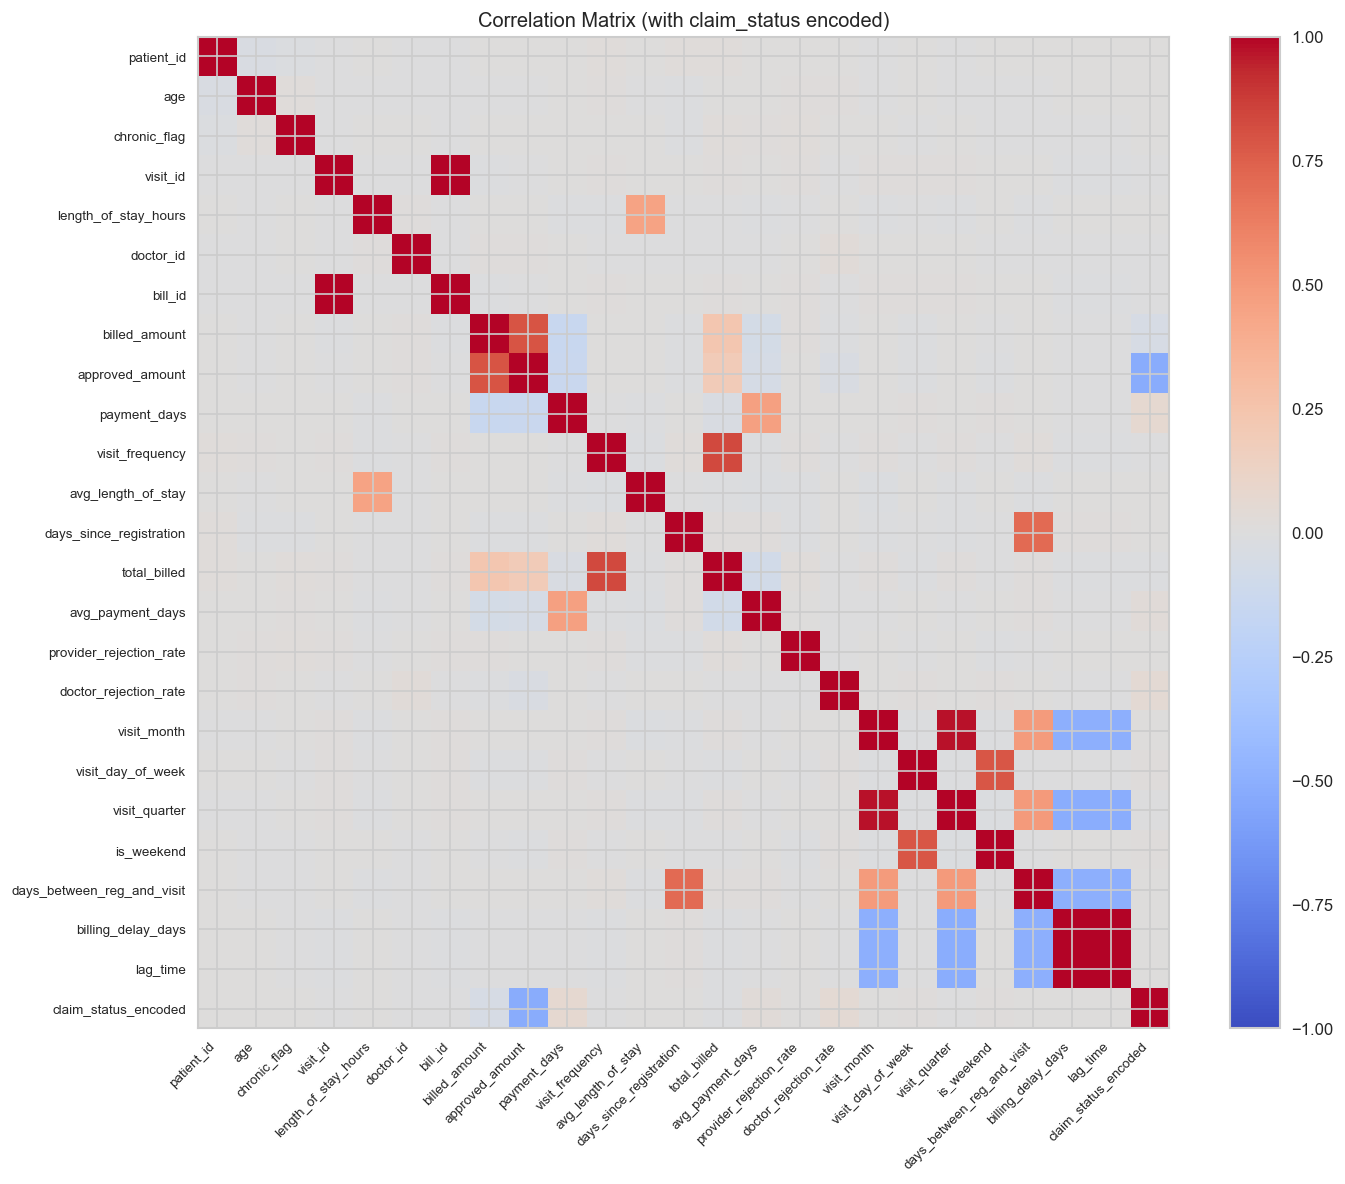


--- Correlation with claim_status ---
approved_amount              -0.519572
payment_days                  0.067441
doctor_rejection_rate         0.053586
billed_amount                -0.050157
avg_payment_days              0.030739
total_billed                 -0.014661
visit_day_of_week             0.011258
is_weekend                    0.010741
days_since_registration       0.007367
age                           0.007278
avg_length_of_stay            0.006915
visit_id                     -0.005888
bill_id                      -0.005888
doctor_id                    -0.005155
billing_delay_days            0.004621
lag_time                      0.004621
chronic_flag                  0.004470
visit_frequency              -0.002761
patient_id                    0.002075
provider_rejection_rate       0.002065
length_of_stay_hours          0.001695
visit_month                   0.000536
days_between_reg_and_visit    0.000440
visit_quarter                -0.000360


In [35]:
# Encode target variable for correlation
df_corr = df.select_dtypes(include=[np.number]).copy()
df_corr["claim_status_encoded"] = LabelEncoder().fit_transform(df["claim_status"])

corr_matrix = df_corr.corr()

# Plot correlation matrix
fig, ax = plt.subplots(figsize=(12, 10))
im = ax.imshow(corr_matrix, cmap="coolwarm", aspect="auto", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr_matrix.columns)))
ax.set_yticks(range(len(corr_matrix.columns)))
ax.set_xticklabels(corr_matrix.columns, rotation=45, ha="right", fontsize=8)
ax.set_yticklabels(corr_matrix.columns, fontsize=8)
plt.colorbar(im, ax=ax)
ax.set_title("Correlation Matrix (with claim_status encoded)")
plt.tight_layout()
plt.show()

# Show correlations with the target sorted by absolute value
print("\n--- Correlation with claim_status ---")
target_corr = corr_matrix["claim_status_encoded"].drop("claim_status_encoded").sort_values(key=abs, ascending=False)
print(target_corr.to_string())

Setting up the ML pipeline...
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002515 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 6880
[LightGBM] [Info] Number of data points in the train set: 35829, number of used features: 27
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612

--- Target Classes ---
['Paid', 'Pending', 'Rejected']
Categories (3, object): ['Paid', 'Pending', 'Rejected']
Training models... This might take a few minutes.


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
gbc,Gradient Boosting Classifier,0.6363,0.0000,0.6363,0.5951,0.5855,0.2370,0.2655,2.6560
lightgbm,Light Gradient Boosting Machine,0.6326,0.6990,0.6326,0.5865,0.5828,0.2323,0.2576,1.7840
ada,Ada Boost Classifier,0.6256,0.0000,0.6256,0.5761,0.5805,0.2285,0.2471,1.1720
xgboost,Extreme Gradient Boosting,0.6226,0.6840,0.6226,0.5734,0.5762,0.2195,0.2393,1.0730
rf,Random Forest Classifier,0.6178,0.6781,0.6178,0.5685,0.5756,0.2191,0.2348,1.6060
et,Extra Trees Classifier,0.6145,0.6710,0.6145,0.5622,0.5677,0.2027,0.2205,1.2480
qda,Quadratic Discriminant Analysis,0.4936,0.0000,0.4936,0.5750,0.5120,0.1899,0.2027,1.0270
nb,Naive Bayes,0.4931,0.6586,0.4931,0.5661,0.5098,0.1793,0.1900,1.0010
knn,K Neighbors Classifier,0.4992,0.5988,0.4992,0.5081,0.5033,0.1163,0.1165,0.9830
dt,Decision Tree Classifier,0.4900,0.5642,0.4900,0.5078,0.4979,0.1135,0.1139,1.0080



--- Best Model Found ---
GradientBoostingClassifier(ccp_alpha=0.0, criterion='friedman_mse', init=None,
                           learning_rate=0.1, loss='log_loss', max_depth=3,
                           max_features=None, max_leaf_nodes=None,
                           min_impurity_decrease=0.0, min_samples_leaf=1,
                           min_samples_split=2, min_weight_fraction_leaf=0.0,
                           n_estimators=100, n_iter_no_change=None,
                           random_state=42, subsample=1.0, tol=0.0001,
                           validation_fraction=0.1, verbose=0,
                           warm_start=False)

Tuning hyperparameters for the best model...


,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.6265,0.0000,0.6265,0.5781,0.5764,0.2200,0.2438
1,0.6340,0.0000,0.6340,0.5886,0.5887,0.2421,0.2639
2,0.6295,0.0000,0.6295,0.5851,0.5856,0.2362,0.2564
3,0.6290,0.0000,0.6290,0.5826,0.5739,0.2170,0.2460
4,0.6385,0.0000,0.6385,0.5972,0.5910,0.2463,0.2725
5,0.6440,0.0000,0.6440,0.6037,0.5985,0.2597,0.2852
6,0.6325,0.0000,0.6325,0.5864,0.5877,0.2432,0.2642
7,0.6145,0.0000,0.6145,0.5583,0.5607,0.1944,0.2164
8,0.6280,0.0000,0.6280,0.5810,0.5810,0.2295,0.2513


Fitting 10 folds for each of 10 candidates, totalling 100 fits
Original model was better than the tuned model, hence it will be returned. NOTE: The display metrics are for the tuned model (not the original one).

--- Final Tuned Hyperparameters ---
{'ccp_alpha': 0.0,
 'criterion': 'friedman_mse',
 'init': None,
 'learning_rate': 0.1,
 'loss': 'log_loss',
 'max_depth': 3,
 'max_features': None,
 'max_leaf_nodes': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'n_estimators': 100,
 'n_iter_no_change': None,
 'random_state': 42,
 'subsample': 1.0,
 'tol': 0.0001,
 'validation_fraction': 0.1,
 'verbose': 0,
 'warm_start': False}

Generating evaluation plots...


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Gradient Boosting Classifier,0.6384,0.6954,0.6384,0.5979,0.5844,0.2270,0.2592


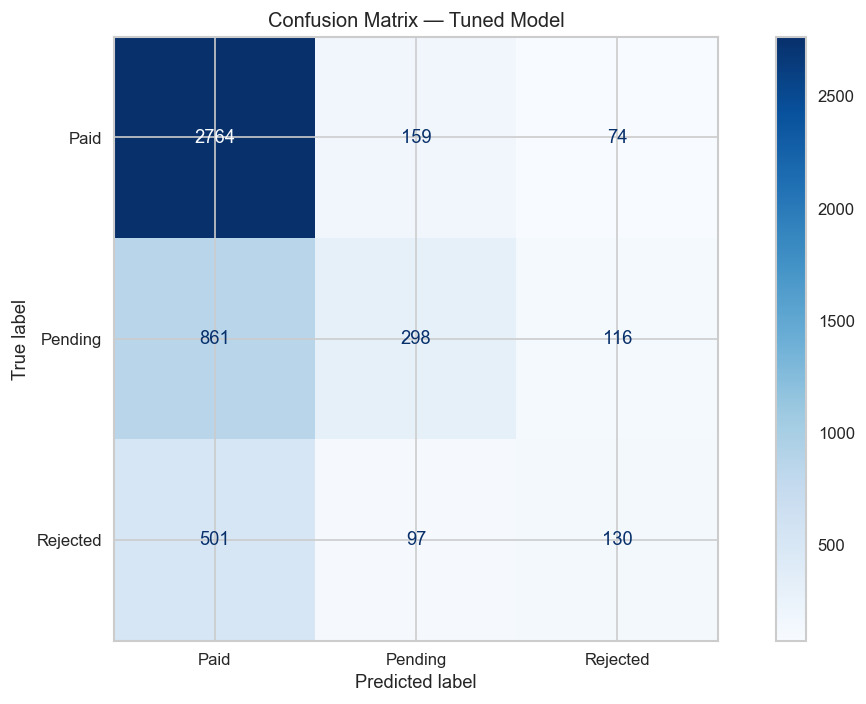

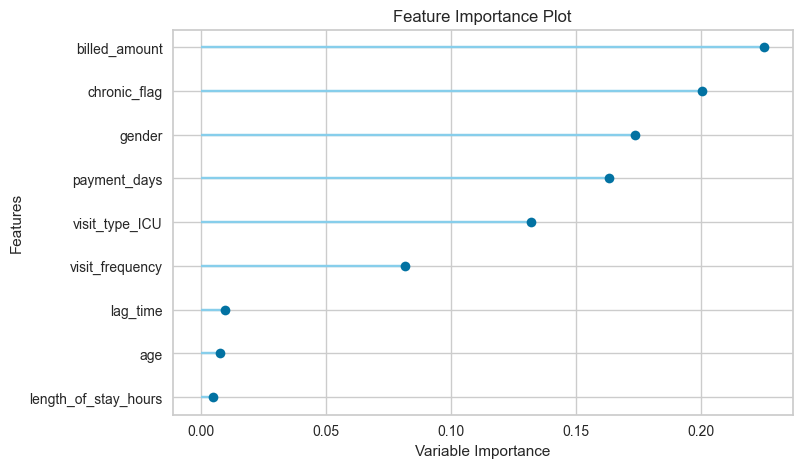

In [36]:
print("Setting up the ML pipeline...")

columns_to_keep = [
    
                   # Essential for demographic profiling. 
                   # Certain age groups or genders may have different coverage limits or frequent claim types.
                    "age"
                   , "gender"

                    # Useful for identifying regional billing patterns or specific provider-insurer agreements in certain locations.
                   , "city"
                    #Critical. Claim approval logic varies significantly between different insurers. 
                    # Some may have stricter documentation requirements or lower approval rates for specific treatments.
                   , "insurance_provider"
                   #Patients with chronic conditions often have complex, recurring claims. 
                   # This is a strong indicator of whether a claim might be flagged for manual review or rejected based on 
                   # pre-existing condition clauses.
                   , "chronic_flag"

                    # (OPD, ER, ICU): High Importance. Emergency (ER) or Intensive Care (ICU) visits are high-stakes and high-cost, 
                    # often leading to more rigorous scrutiny from insurance providers compared to routine Outpatient (OPD) visits.
                    ,"visit_type"

                    # Helps identify if certain specialties
                    #  (e.g., Cardiology vs. General Medicine) have higher rejection rates due to the nature of the procedures.
                    , "department"

                    #A proxy for medical necessity. 
                    # Extremely short stays for expensive procedures, or unusually long stays, are often red flags for insurers.
                    , "length_of_stay_hours"
       
                    # Critical. Larger bills are statistically more likely to be audited, disputed, or partially rejected by insurers.
                    , "billed_amount"
                    , "lag_time"
                    # While this is a post-claim metric, in a training environment, historical patterns of how long a 
                    # provider takes to pay can correlate with the likelihood of an initial rejection or "Pending" status.
                    , "payment_days"
                    # Repeat patient, increase in billing amount, or risk scores
                    , "visit_frequency"
                   ]

columns_to_drop = [col for col in df.columns if col not in columns_to_keep and col != "claim_status"]


# df is already sorted by visit_date (done at load time) — no shuffling, no data leakage

# Aggressive SMOTE for minority classes (Pending, Rejected)
smote = SMOTE(sampling_strategy="not majority", random_state=RANDOM_STATE)

clf_setup = setup(
    data=df, 
    target="claim_status", 
    ignore_features=columns_to_drop,
    session_id=RANDOM_STATE,               # Keeps results reproducible
    train_size=0.8,              # Earliest 80% for training, latest 20% for testing
    data_split_shuffle=False,    # Preserves chronological order — test set = future data
    data_split_stratify=False,   # Stratification requires shuffle; disabled for time-based split
    fix_imbalance=True,          # Enable imbalance handling
    fix_imbalance_method=smote,  # Use SMOTE to oversample Pending & Rejected
    normalize=True,              # Scales numerical data
    feature_selection=True,      # Automatically drops weak features
    n_features_to_select=0.8,    # Keeps the top 80% of features
    remove_multicollinearity=True,
    multicollinearity_threshold=0.9,
    system_log=False,
    verbose=False
)


print("\n--- Target Classes ---")
print(get_config("y").unique())


# Train and Compare Models — optimize MCC to penalize bias toward majority class
print("Training models... This might take a few minutes.")
best_model = compare_models(sort="MCC")



print("\n--- Best Model Found ---")
print(best_model)

# Tune the Best Model — optimize MCC so Rejected/Pending aren't sacrificed
print("\nTuning hyperparameters for the best model...")
tuned_model = tune_model(best_model, optimize="MCC")

# Get best hyperparameters
print("\n--- Final Tuned Hyperparameters ---")

pprint.pprint(tuned_model.get_params())

# Visual Evaluation
print("\nGenerating evaluation plots...")



y_test = get_config("y_test")
y_pred = predict_model(tuned_model)["prediction_label"]

ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=sorted(df["claim_status"].unique()), cmap="Blues")
plt.title("Confusion Matrix — Tuned Model")
plt.tight_layout()
plt.show()

plot_model(tuned_model, plot="feature") # See which health factors matter most

In [37]:
# ============================================================
# Finalize & Save Model
# ============================================================

print("Finalizing model for production...")
final_production_model = finalize_model(tuned_model)

# Save the Pipeline to Model Files directory
model_name = "../../Model Files/claim_outcome_model"
save_model(final_production_model, model_name)
print(f"\nSuccess! Model saved as '{model_name}.pkl'.")

Finalizing model for production...
Transformation Pipeline and Model Successfully Saved

Success! Model saved as '../../Model Files/claim_outcome_model.pkl'.


In [38]:
import json
from pycaret.classification import get_config

# 1. Pull the transformed feature set from PyCaret
X_train = get_config("X_train")
feature_types = X_train.dtypes.to_dict()

# 2. Build the schema dictionary
schema = {
    "version": "1.0",
    "target": get_config("target_param"),
    "features": []
}

for col, dtype in feature_types.items():
    feature_entry = {
        "name": col,
        "type": str(dtype),
        "required": True
    }

    # Custom Validation: claim-specific constraints
    if col == "chronic_flag":
        feature_entry["constraints"] = {
            "allowed_values": [0, 1]
        }

    if col == "gender":
        feature_entry["constraints"] = {
            "allowed_values": ["M", "F"]
        }

    if col == "visit_frequency":
        feature_entry["constraints"] = {
            "min_value": 1
        }

    if col == "billed_amount":
        feature_entry["constraints"] = {
            "min_value": 0
        }

    if col == "payment_days":
        feature_entry["constraints"] = {
            "min_value": 0
        }

    schema["features"].append(feature_entry)

# 3. Export to JSON file
schema_path = "../../Model Files/claim_outcome_model_feature_schema.json"
with open(schema_path, "w") as f:
    json.dump(schema, f, indent=4)

print(f"Feature schema saved to '{schema_path}'.")
print(json.dumps(schema, indent=4))

Feature schema saved to '../../Model Files/claim_outcome_model_feature_schema.json'.
{
    "version": "1.0",
    "target": "claim_status",
    "features": [
        {
            "name": "age",
            "type": "int8",
            "required": true
        },
        {
            "name": "gender",
            "type": "category",
            "required": true,
            "constraints": {
                "allowed_values": [
                    "M",
                    "F"
                ]
            }
        },
        {
            "name": "city",
            "type": "category",
            "required": true
        },
        {
            "name": "insurance_provider",
            "type": "category",
            "required": true
        },
        {
            "name": "chronic_flag",
            "type": "int8",
            "required": true,
            "constraints": {
                "allowed_values": [
                    0,
                    1
                ]
            }